<!-- # Fagprojekt -->

In [37]:
from pathlib import Path
import os

import numpy as np
import vedo
from vedo import settings
from PIL import Image
from skimage.measure import label, regionprops

from skimage import io
from skimage.filters import threshold_multiotsu, threshold_otsu

import torch
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.metrics.pairwise import cosine_similarity
import math

from dataclasses import asdict, dataclass
from pathlib import Path
import json
import argparse
from PIL import Image, ImageDraw
from vtkmodules.vtkRenderingCore import vtkCoordinate
import tempfile

from types import SimpleNamespace
import tifffile
import time

settings.default_backend = "vtk"

<!-- ## Part 1 - Computer grafik -->

<!-- ### Segmentation -->

In [38]:
zoom = 1.2
fov = 30
camera_fov = fov / zoom
patch_size = 16
grid_h = 60
grid_w = 60
render_size = (grid_h * patch_size, grid_w * patch_size)


original_path = Path("data/original_photos")
out_path = Path("data/test/final_segmented")
# Almost white
bg_threshold = 240
# Ratio of foreground to background to include patch
fg_patch_ratio = 0.2

# label, direction, view_up
VIEWS = [
    ("+X", np.array([1, 0, 0]), np.array([0, 0, 1])),
    ("-X", np.array([-1, 0, 0]), np.array([0, 0, 1])),
    ("+Y", np.array([0, 1, 0]), np.array([0, 0, 1])),
    ("-Y", np.array([0, -1, 0]), np.array([0, 0, 1])),
    ("+Z", np.array([0, 0, 1]), np.array([0, 1, 0])),
    ("-Z", np.array([0, 0, -1]), np.array([0, 1, 0])),]


animals = ["AC", "BC", "BF", "BL", "BP", "CF", "GH", "MA", "PP", "WO"]

# Small
#model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
# Base
model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Starting top3 head patch run | model={model_name} | device={device}")
print("Loading DINO processor...")
processor = AutoImageProcessor.from_pretrained(model_name)
print("Loading DINO model...")
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()
print("Model loaded.")
patch_size = int(getattr(model.config, "patch_size", 16))
num_register_tokens = int(getattr(model.config, "num_register_tokens", 0))
num_prefix_tokens = 1 + num_register_tokens  # CLS + register tokens
print(f"patch_size={patch_size} | num_register_tokens={num_register_tokens}")

Starting top3 head patch run | model=facebook/dinov3-vitb16-pretrain-lvd1689m | device=cpu
Loading DINO processor...
Loading DINO model...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Model loaded.
patch_size=16 | num_register_tokens=4


In [39]:
# Finds all .tif files in folders and subfolders of input
def find_input_volumes(in_root: Path) -> list[Path]:
    files = (f for f in in_root.rglob("*.tif"))
    return sorted(files)

find_input_volumes(original_path)
1

1

In [40]:
def segment_largest_component(volume: np.ndarray) -> np.ndarray:
    thresholds = threshold_otsu(volume)
    mask = volume > thresholds

    mask = ndimage.binary_dilation(mask,iterations=5)
    mask = ndimage.binary_fill_holes(mask)

    labeled, num = ndimage.label(mask)

    # Weighted sum of the components
    sizes = ndimage.sum_labels(volume, labeled, index=np.arange(1, num + 1))
    
    # Finds largest weight and return
    largest = int(np.argmax(sizes) + 1)
    mask = labeled == largest
    return mask

In [41]:
def render_views(
    clean_volume: np.ndarray,
    out_dir: Path,
    base_name: str,
) -> dict[str, object]:
    vol = vedo.Volume(clean_volume)
    # Locate corners
    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    p_min, p_max = np.array([xmin, ymin, zmin]), np.array([xmax, ymax, zmax])

    # Calculate camera position
    center = (p_min + p_max) / 2
    diag = np.linalg.norm(p_max - p_min)
    distance = max(diag * 1.5, 1.0)
    camera_views: list[dict[str, object]] = []

    plotter = vedo.Plotter(size=render_size, offscreen=True, bg="white")
    try:
        for label, direction, view_up in VIEWS:
            plotter.clear()
            plotter.show(vol, resetcam=True, zoom=zoom)

            cam = plotter.camera
            cam.SetFocalPoint(*center)
            cam.SetPosition(*(center + direction * distance))
            cam.SetViewUp(*view_up)
            plotter.renderer.ResetCameraClippingRange()

            out_path = out_dir / f"{base_name}_{label}.png"
            plotter.screenshot(str(out_path))

            fov_y_deg = float(cam.GetViewAngle())
            cam_pos = (center + direction * distance).tolist()
            camera_views.append(
                {
                    "angle":              label,
                    "direction":          direction.astype(float).tolist(),
                    "view_up":            view_up.astype(float).tolist(),
                    "camera_position":    cam_pos,
                    "camera_focal_point": center.astype(float).tolist(),
                    "fov_y_deg":          fov_y_deg,
                    "image_width":        int(render_size[0]),
                    "image_height":       int(render_size[1]),
                    "output_image":       str(out_path),
                }
            )
    finally:
        plotter.close()

    return {
        "bounds_xyzxyz": [float(xmin), float(xmax), float(ymin), float(ymax), float(zmin), float(zmax)],
        "volume_center_xyz": center.astype(float).tolist(),
        "camera_distance": float(distance),
        "camera_views": camera_views,
    }

In [42]:
def process_volume(in_path: Path, in_root: Path, out_root: Path) -> Path:
    # Finds the file positions
    # Finds the species from file
    rel_parent = in_path.parent.relative_to(in_root)
    # Builds ouput path
    out_dir = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    data = vedo.load(str(in_path)).tonumpy()
    mask = segment_largest_component(data)

    # Save mask
    np.savez_compressed(out_dir / "mask.npz", mask=mask)

    clean_data = np.zeros_like(data)
    clean_data[mask] = data[mask]
    render_meta = render_views(clean_data, out_dir=out_dir, base_name=in_path.stem)

    # Voxel axis convention for numpy volume arrays from vedo in this project: [x, y, z].
    shape_xyz = [int(data.shape[0]), int(data.shape[1]), int(data.shape[2])]

    metadata = {
        "source_path": str(in_path),
        "output_dir": str(out_dir),
        "volume_shape": shape_xyz, 
        "kept_voxels": int(mask.sum()),
        "total_voxels": int(mask.size),
        "render_geometry": render_meta,
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return out_dir

In [43]:
# process_volume(original_path / Path("AC/bcrick_1_000.tif"), original_path, Path(r"data\new_photos_dinov3\segmented"))

# Finding head

In [44]:
def patch_from_pixel(
    x: float,
    y: float,
    patch_size: int,
) -> dict[str, float | int]:
    col = int(x // patch_size)
    row = int(y // patch_size)

    x0 = col * patch_size
    y0 = row * patch_size

    x1 = x0 + patch_size - 1
    y1 = y0 + patch_size - 1

    center_x = x0 + (x1 - x0 + 1) / 2.0
    center_y = y0 + (y1 - y0 + 1) / 2.0

    return {
        "patch_col": col,
        "patch_row": row,
        "patch_x0": int(x0),
        "patch_y0": int(y0),
        "patch_x1": int(x1),
        "patch_y1": int(y1),
        "patch_center_x": float(center_x),
        "patch_center_y": float(center_y),
    }

In [45]:
def camera_basis(cam_pos: np.ndarray, focal: np.ndarray, view_up: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Gets right, up and front unit vectors for a camera position
    f = focal - cam_pos
    f = f / np.linalg.norm(f)
    # View up, but not orthogonal
    u0 = view_up / np.linalg.norm(view_up)
    # Right
    r = np.cross(f, u0)
    r = r / max(np.linalg.norm(r), 1e-12)
    # Orthogonal view up
    u = np.cross(r, f)
    u = u / max(np.linalg.norm(u), 1e-12)
    return r, u, f

In [46]:
def project_point_to_pixel(
    point_xyz: np.ndarray,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    image_w: int,
    image_h: int,
    fov_y_deg: float,
) -> tuple[float, float, float]:
    """
    Forward perspective projection: world point -> pixel (top-left origin, y down).
    Exact inverse of build_ray_from_pixel.
    Returns (px, py, depth); depth <= 0 means the point is behind the camera.
    """
    r, u, f = camera_basis(cam_pos, focal, view_up)

    w = point_xyz - cam_pos

    depth = float(np.dot(w, f))
    x_cam = float(np.dot(w, r))
    y_cam = float(np.dot(w, u))

    tan_half = math.tan(math.radians(fov_y_deg) * 0.5)

    x_ndc = (x_cam / depth) / (tan_half)
    y_ndc = (y_cam / depth) / tan_half

    nx = x_ndc * 0.5 + 0.5
    ny = 0.5 - y_ndc * 0.5

    return nx * image_w, ny * image_h, depth

In [47]:
def get_head_information(
    in_path: Path,
    in_root: Path,
    out_root: Path,
    annotation_xyz: list[int],
) -> dict[str, dict[str, object]]:

    rel_parent = in_path.parent.relative_to(in_root)
    out_dir    = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    meta_path    = out_dir / "metadata.json"
    metadata     = json.loads(meta_path.read_text(encoding="utf-8"))
    camera_views = metadata["render_geometry"]["camera_views"]

    world_point = annotation_xyz
    out: dict[str, dict[str, object]] = {}

    for view in camera_views:
        label   = view["angle"]
        cam_pos = np.array(view["camera_position"],    dtype=float)
        focal   = np.array(view["camera_focal_point"], dtype=float)
        view_up = np.array(view["view_up"],            dtype=float)
        fov_y   = float(view["fov_y_deg"])
        image_w = int(view["image_width"])
        image_h = int(view["image_height"])

        px, py, depth = project_point_to_pixel(
            world_point, cam_pos, focal, view_up, image_w, image_h, fov_y,
        )

        patch = patch_from_pixel(px, py, image_w, image_h, patch_size)

        # Filter out the unnecessary metadata
        out[label] = {
            "head_x":         round(px, 3),
            "head_y":         round(py, 3),
            "depth":          round(depth, 3),
            "image_width":    image_w,
            "image_height":   image_h,
            "patch_size":     patch_size,
            "patch_col":      patch["patch_col"],
            "patch_row":      patch["patch_row"],
            "patch_x0":       patch["patch_x0"],
            "patch_y0":       patch["patch_y0"],
            "patch_x1":       patch["patch_x1"],
            "patch_y1":       patch["patch_y1"],
            "patch_center_x": round(float(patch["patch_center_x"]), 3),
            "patch_center_y": round(float(patch["patch_center_y"]), 3),
        }

    out_path = out_dir / "head_projection.json"
    out_path.write_text(json.dumps(out, indent=2), encoding="utf-8")
    return out

# DINOv3

In [48]:
def make_foreground_patch_mask(
    image: Image.Image,
    bg_threshold: int,
    fg_patch_ratio: float,
) -> tuple[np.ndarray, int, int]:
    # Finds foreground patches

    img = np.array(image)

    # Foreground pixels
    # Check that all RGB values are under the threshold
    fg_pixel = np.all(img < bg_threshold, axis=2)

    # Reshape into patches and compute foreground fraction per patch
    patches = fg_pixel.reshape(
        grid_h, patch_size,
        grid_w, patch_size
    )

    # Average of fg_pixel over each patch
    fg_fraction = patches.mean(axis=(1, 3))

    fg_patch = fg_fraction > fg_patch_ratio

    return fg_patch.ravel()

In [49]:
def extract_patch_tokens(
    image_path: Path,
    processor: AutoImageProcessor,
    model: AutoModel,
    device: str,
) -> None:
    parts = image_path.parts
    seg_idx = parts.index("segmented")
    # Makes token dir
    token_dir = Path(*parts[:seg_idx]) / "tokens" / Path(*parts[seg_idx + 1:]).parent / image_path.stem
    token_dir.mkdir(parents=True, exist_ok=True)

    tokens_path  = token_dir / "tokens.npy"

    if tokens_path.exists():
        return None

    image = Image.open(image_path).convert("RGB")

    with torch.inference_mode():
        inputs = processor(
            images=image,
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False,
        )
        pixel_values = inputs["pixel_values"].to(device)
        outputs = model(pixel_values)
        patch_tokens = outputs.last_hidden_state[:, num_prefix_tokens:, :].squeeze(0).cpu().numpy()

    np.save(tokens_path, patch_tokens)

    return None

In [50]:
def discover_segmented_individuals(segmented_root: Path, animal: str) -> list[str]:
    # Finds the segmented individuals by the subfolders of the animal
    species_dir = segmented_root / animal
    if not species_dir.exists():
        return []
    return sorted(p.name for p in species_dir.iterdir() if p.is_dir())

In [51]:
def extract_patch_tokens_animal(
    segmented_root: Path,
    animal: str,
    processor: AutoImageProcessor,
    model: AutoModel,
    patch_size: int,
    bg_threshold: int,
    fg_patch_ratio: float,
    device: str,
) -> None:
    
    segmented_individuals = discover_segmented_individuals(segmented_root, animal)

    for individual in segmented_individuals:
        for angle, _, _ in VIEWS:
            image_path = segmented_root / animal / individual / f'{individual}_{angle}.png'
            extract_patch_tokens(
                    image_path,
                    processor,
                    model,
                    patch_size,
                    bg_threshold,
                    fg_patch_ratio,
                    device,
            )
    return None

In [52]:
def build_prototype_animal(
    animal: str,
    tokens_root: Path,
    segmented_root: Path,
):
    individuals = discover_segmented_individuals(segmented_root, animal)

    proto_list = []

    for individual in individuals:
        head_info_path = segmented_root / animal / individual / "head_projection.json"
        
        if not head_info_path.exists():
            continue
        
        # Has angle:data format
        head_info = json.loads(head_info_path.read_text(encoding="utf-8"))

        for angle, angle_info in head_info.items():
            patch_row = int(angle_info["patch_row"])
            patch_col = int(angle_info["patch_col"])

            # Token files are per render image, named by scan + angle
            # e.g. data/test/tokens/AC/bcrick_1_000/bcrick_1_000_1_+X/
            tokens_path = tokens_root / animal / individual / f"{individual}_{angle}" / "tokens.npy"

            if not Path.exists(tokens_path):
                continue

            tokens = np.load(tokens_path, mmap_mode="r")  # (n_patches, embed_dim)

            idx = patch_row * grid_w + patch_col
            token = tokens[idx].copy()
            proto_list.append(token)
    
    if not proto_list:
        raise ValueError(f"No prototype vectors could be built for animal '{animal}'")

    prototype_vector = np.mean(proto_list, axis=0)

    np.save(tokens_root / animal / "prototype_vector.npy", prototype_vector)

    return prototype_vector

In [53]:
def plot_patch_similarity(head_vector, tokens):
    sims = cosine_similarity([head_vector], tokens)
    sim_map = sims.reshape(70,70)
    plt.imshow(sim_map, cmap="jet")
    plt.colorbar()
    plt.title("Patch similarity map")
    plt.axis("off")
    plt.show()

In [ ]:
def save_cosine_similarities(tokens_root: Path, animal: str):
    path_prototype = tokens_root / animal / "prototype_vector.npy"
    prototype_vector = np.load(path_prototype)  # (embed_dim,)

    individuals = discover_segmented_individuals(tokens_root, animal)

    for individual in individuals:
        individual_dir = tokens_root / animal / individual

        for angle_dir in sorted(individual_dir.iterdir()):
            if not angle_dir.is_dir():
                continue

            tokens_path  = angle_dir / "tokens.npy"
            fg_flat_path = angle_dir / "fg_flat.npy"
            out_path     = angle_dir / "cosine_similarity.npy"

            if not tokens_path.exists() or not fg_flat_path.exists():
                continue

            tokens  = np.load(tokens_path)   # (n_patches, embed_dim)
            fg_flat = np.load(fg_flat_path)  # (n_patches,) bool

            sims = np.full(tokens.shape[0], np.nan)
            sims[fg_flat] = cosine_similarity(
                tokens[fg_flat],
                prototype_vector.reshape(1, -1),
            ).squeeze(1)

            np.save(out_path, sims)

In [20]:
def save_top_k_patches(tokens_root: Path, animal: str, k: int):
    lst_individuals = discover_segmented_individuals(tokens_root, animal)

    for individual in lst_individuals:
        individual_dir = tokens_root / animal / individual

        for angle_dir in sorted(individual_dir.iterdir()):
            if not angle_dir.is_dir():
                continue

            sims_path = angle_dir / "cosine_similarity.npy"
            out_path  = angle_dir / "top_k_patches.json"

            if not sims_path.exists():
                log(f"  [{animal} {individual}] skipping {angle_dir.name} — cosine_similarity.npy not found")
                continue

            sims    = np.load(sims_path)        # (n_patches,) with nan for background
            fg_mask = ~np.isnan(sims)           # foreground indices

            fg_indices = np.where(fg_mask)[0]
            fg_sims    = sims[fg_indices]

            if len(fg_indices) == 0:
                log(f"  [{animal} {individual}] skipping {angle_dir.name} — no foreground patches")
                continue

            actual_k      = min(k, len(fg_indices))
            top_k_order   = np.argsort(fg_sims)[::-1][:actual_k]
            top_k_flat    = fg_indices[top_k_order]

            grid_w = int(render_size[0] / patch_size)

            top_k_patches = []
            for rank, flat_idx in enumerate(top_k_flat):
                row = int(flat_idx // grid_w)
                col = int(flat_idx % grid_w)
                top_k_patches.append({
                    "rank":            rank,
                    "flat_idx":        int(flat_idx),
                    "patch_row":       row,
                    "patch_col":       col,
                    "patch_x0":        col * patch_size,
                    "patch_y0":        row * patch_size,
                    "patch_x1":        col * patch_size + patch_size-1,
                    "patch_y1":        row * patch_size + patch_size-1,
                    "cosine_similarity": float(sims[flat_idx]),
                })

            out_path.write_text(
                json.dumps({"k": actual_k, "patches": top_k_patches}, indent=2),
                encoding="utf-8",
            )
            log(f"  [{animal} {individual}] saved top-{actual_k} patches: {angle_dir.name}")

In [21]:
def build_rays_from_top_k_patches(
    top_k_patches_path: Path,
    image_w: int,
    image_h: int,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    fov_y_deg: float,
    patch_size: int = patch_size,
):
    """
    Loads top_k_patches.json and converts patches into 3D rays.

    Returns:
        origins: (K, 3)
        dirs:    (K, 3)
        meta:    list of patch metadata
    """

    data = json.loads(top_k_patches_path.read_text(encoding="utf-8"))
    patches = data["patches"]

    origins = []
    dirs = []
    meta = []

    for p in patches:
        row = p["patch_row"]
        col = p["patch_col"]

        # convert patch → pixel center
        px = (col + 0.5) * patch_size
        py = (row + 0.5) * patch_size

        # normalize to [0,1]
        nx = px / float(image_w)
        ny = py / float(image_h)

        origin, direction = build_ray_from_pixel(
            nx=nx,
            ny=ny,
            image_w=image_w,
            image_h=image_h,
            cam_pos=cam_pos,
            focal=focal,
            view_up=view_up,
            fov_y_deg=fov_y_deg,
        )

        origins.append(origin)
        dirs.append(direction)

        meta.append({
            "rank": p["rank"],
            "flat_idx": p["flat_idx"],
            "cosine_similarity": p["cosine_similarity"],
            "patch_row": row,
            "patch_col": col,
        })

    return np.asarray(origins), np.asarray(dirs), meta

<!-- ### Rays -->

In [22]:
def load_camera_by_angle(segmented_meta: Path) -> dict[str, dict[str, object]]:
    d = json.loads(segmented_meta.read_text(encoding="utf-8"))
    views = d.get("render_geometry", {}).get("camera_views", [])
    out: dict[str, dict[str, object]] = {}
    for v in views:
        angle = v.get("angle")
        if angle in ANGLE_NAMES:
            out[angle] = v
    return out

In [24]:
def build_ray_from_pixel(
    nx: float,
    ny: float,
    image_w: int,
    image_h: int,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    fov_y_deg: float,
) -> tuple[np.ndarray, np.ndarray]:
    x_ndc = (nx - 0.5) * 2.0
    y_ndc = (0.5 - ny) * 2.0
    aspect = float(image_w) / max(float(image_h), 1.0)
    tan_half = np.tan(np.deg2rad(fov_y_deg) * 0.5)

    d_cam = np.array([x_ndc * aspect * tan_half, y_ndc * tan_half, 1.0], dtype=float)
    d_cam = d_cam / max(np.linalg.norm(d_cam), 1e-12)

    r, u, f = camera_basis(cam_pos, focal, view_up)
    d_world = d_cam[0] * r + d_cam[1] * u + d_cam[2] * f
    d_world = d_world / max(np.linalg.norm(d_world), 1e-12)
    return cam_pos, d_world

In [25]:
def triangulate_rays(origins: list[np.ndarray], dirs: list[np.ndarray]) -> tuple[np.ndarray, float]:
    A = np.zeros((3, 3), dtype=float)
    b = np.zeros(3, dtype=float)

    for o, d in zip(origins, dirs):
        d = d / max(np.linalg.norm(d), 1e-12)
        M = np.eye(3) - np.outer(d, d)
        A += M
        b += M @ o

    p = np.linalg.solve(A + np.eye(3) * 1e-9, b)

    dists = []
    for o, d in zip(origins, dirs):
        d = d / max(np.linalg.norm(d), 1e-12)
        dists.append(float(np.linalg.norm(np.cross(p - o, d))))

    return p, float(np.mean(dists))

In [27]:
def point_ray_distance(p: np.ndarray, o: np.ndarray, d: np.ndarray) -> float:
    d = d / max(np.linalg.norm(d), 1e-12)
    return float(np.linalg.norm(np.cross(p - o, d)))

In [ ]:
def build_rays_from_individual(segmented_root: Path, tokens_root: Path, animal: str, individual: str):
    seg_meta = segmented_root / animal / individual / "metadata.json"

    cam_by_angle = load_camera_by_angle(seg_meta)

    origins = []
    dirs = []
    weights = []
    per_angle = {}
    volume_shape_xyz = None

    for i, angle in enumerate(angles):
        cam = cam_by_angle[angle]


        print(angle, cam["camera_position"])

        cam_pos = np.array(cam["camera_position"], dtype=float)
        focal = np.array(cam["camera_focal_point"], dtype=float)
        view_up = np.array(cam["view_up"], dtype=float)

        angles_root = tokens_root / animal

        angle_paths = discover_segmented_individuals(angles_root, individual)

        for path in angle_paths:
            json_path = angles_root / individual / path / "top_k_patches.json"
            top_k_json = json.loads(json_path.read_text(encoding="utf-8"))['patches']

            for patch in top_k_json:
                nx = ((patch['patch_x0'] + patch['patch_x1']) / 2.0) / render_size[0]
                ny = ((patch['patch_y0'] + patch['patch_y1']) / 2.0) / render_size[1]

                image_w = render_size[0]
                image_h = render_size[1]

                origin, direction = build_ray_from_pixel(
                    nx,
                    ny,
                    image_w,
                    image_h,
                    cam_pos,
                    focal,
                    view_up,
                    fov_y_deg=camera_fov,
                )

                origins.append(origin)
                dirs.append(direction)

    return origins, dirs

In [ ]:
def build_rays_from_individual(segmented_root: Path, tokens_root: Path, animal: str, individual: str):
    seg_meta = segmented_root / animal / individual / "metadata.json"
    cam_by_angle = load_camera_by_angle(seg_meta)

    origins = []
    dirs = []

    for angle in angles:
        if angle not in cam_by_angle:
            continue

        cam = cam_by_angle[angle]
        cam_pos = np.array(cam["camera_position"], dtype=float)
        focal   = np.array(cam["camera_focal_point"], dtype=float)
        view_up = np.array(cam["view_up"], dtype=float)

        # Find the folder matching this specific angle
        angle_idx = ANGLE_TO_INDEX[angle]
        angle_dir = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}"
        json_path = angle_dir / "top_k_patches.json"

        if not json_path.exists():
            log(f"  [{animal} {individual} {angle}] top_k_patches.json not found")
            continue

        patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]

        for patch in patches:
            nx = ((patch["patch_x0"] + patch["patch_x1"]) / 2.0) / render_size[0]
            ny = ((patch["patch_y0"] + patch["patch_y1"]) / 2.0) / render_size[1]

            origin, direction = build_ray_from_pixel(
                nx=nx,
                ny=ny,
                image_w=render_size[0],
                image_h=render_size[1],
                cam_pos=cam_pos,
                focal=focal,
                view_up=view_up,
                fov_y_deg=camera_fov,
            )

            origins.append(origin)
            dirs.append(direction)

    return origins, dirs

In [30]:
def ransac_fuse(
    origins: list[np.ndarray],
    dirs: list[np.ndarray],
    threshold: float,
    refine_iters: int,
) -> dict | None:
    if len(origins) < 2:
        return None

    best: tuple[int, np.ndarray, list[int]] | None = None

    for i in range(len(origins)):
        for j in range(i + 1, len(origins)):
            p, _ = triangulate_rays(
                [origins[i], origins[j]],
                [dirs[i], dirs[j]],
            )

            inliers = [
                k for k in range(len(origins))
                if point_ray_distance(p, origins[k], dirs[k]) <= threshold
            ]

            if best is None or len(inliers) > best[0]:
                best = (len(inliers), p, inliers)

    if best is None:
        return None

    _, p, inliers = best
    for _ in range(max(0, refine_iters)):
        if len(inliers) < 2:
            break
        p, _ = triangulate_rays(
            [origins[k] for k in inliers],
            [dirs[k] for k in inliers],
        )
        inliers = [
            k for k in range(len(origins))
            if point_ray_distance(p, origins[k], dirs[k]) <= threshold
        ]

    return {
        "point":     p,
        "inliers":   inliers,
        "n_inliers": len(inliers),
        "threshold": threshold,
    }

<!-- ### Rotating -->

In [31]:
def axis_to_vector(axis: str) -> np.ndarray:
    m = {
        "+X": np.array([1.0, 0.0, 0.0], dtype=float),
        "-X": np.array([-1.0, 0.0, 0.0], dtype=float),
        "+Y": np.array([0.0, 1.0, 0.0], dtype=float),
        "-Y": np.array([0.0, -1.0, 0.0], dtype=float),
        "+Z": np.array([0.0, 0.0, 1.0], dtype=float),
        "-Z": np.array([0.0, 0.0, -1.0], dtype=float),
    }
    return m[axis]

In [32]:
def rotation_matrix_from_vectors(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a.astype(float)
    b = b.astype(float)
    a /= max(np.linalg.norm(a), 1e-12)
    b /= max(np.linalg.norm(b), 1e-12)

    v = np.cross(a, b)
    c = float(np.dot(a, b))
    s = float(np.linalg.norm(v))

    if s < 1e-12:
        if c > 0.0:
            return np.eye(3, dtype=float)
        # 180-degree rotation around any axis orthogonal to a.
        axis = np.array([1.0, 0.0, 0.0], dtype=float)
        if abs(np.dot(axis, a)) > 0.9:
            axis = np.array([0.0, 1.0, 0.0], dtype=float)
        axis = axis - np.dot(axis, a) * a
        axis /= max(np.linalg.norm(axis), 1e-12)
        x, y, z = axis
        return np.array(
            [
                [2 * x * x - 1, 2 * x * y, 2 * x * z],
                [2 * y * x, 2 * y * y - 1, 2 * y * z],
                [2 * z * x, 2 * z * y, 2 * z * z - 1],
            ],
            dtype=float,
        )

    vx = np.array(
        [
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0],
        ],
        dtype=float,
    )
    r = np.eye(3, dtype=float) + vx + (vx @ vx) * ((1.0 - c) / (s * s))
    return r

In [33]:
def rotate_volume(volume: np.ndarray, rot: np.ndarray, order: int) -> np.ndarray:
    # ndimage.affine_transform maps output coords -> input coords.
    # For forward rotation R around center c, use R^-1 and offset c - R^-1 c.
    center = (np.array(volume.shape, dtype=float) - 1.0) / 2.0
    r_inv = rot.T
    offset = center - r_inv @ center
    rotated = ndimage.affine_transform(
        volume,
        matrix=r_inv,
        offset=offset,
        order=order,
        mode="constant",
        cval=0.0,
        prefilter=order > 1,
    )
    return rotated

<!-- ### Run all -->

In [ ]:
def run_all(original_path, info_path):
    info_path.mkdir(parents=True, exist_ok=True)
    
    path_anno = Path("Annoteringer/annotations_output/image_annotations.json")
    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    volumes    = find_input_volumes(original_path)
    input_root = original_path
    output_root = info_path / "segmented"

    for i, f in enumerate(volumes):
        animal_key = str(f.parts[-2])
        if animal_key not in animals:
            continue
        print(f"Processing volume:", f.name)
        process_volume(f, input_root, output_root)
    
    
    for i, f in enumerate(volumes):
        animal_key     = str(f.parts[-2])
        individual_key = str(f.parts[-1])
        if animal_key not in animals:
            continue

        print(f"Getting head information:", f.name)

        if animal_key not in annotations or individual_key not in annotations[animal_key]:
            log(f"  skipping {f.name} — not in annotations")
            continue

        if not f.exists():
            log(f"  skipping {f.name} — file not found")
            continue

        annotation_xyz = annotations[animal_key][individual_key]
        get_head_information(f, input_root, output_root, annotation_xyz)

    tokens_root     = info_path / "tokens"
    head_cords_root = info_path / "segmented"
    segmented_root  = info_path / "segmented"

    for animal in animals:
        extract_patch_tokens_animal(segmented_root, animal, processor, model, patch_size, bg_threshold, fg_patch_ratio, device)

    for animal in animals:
        # check if already exists
        prototype = build_prototype_animal(animal, tokens_root, head_cords_root)

    for animal in animals:
        save_cosine_similarities(tokens_root, animal)

    for animal in animals:
        save_top_k_patches(tokens_root, animal, k=4)

    for animal in animals:
        individuals = discover_segmented_individuals(tokens_root, animal)
        for individual in individuals:
            origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)

            if len(origins) < 2:
                log(f"  [{animal} {individual}] skipping — not enough rays")
                continue

            result_ransac = ransac_fuse(origins, dirs, threshold=10, refine_iters=4)

            if result_ransac is None:
                log(f"  [{animal} {individual}] skipping — RANSAC failed")
                continue

            head_xyz = result_ransac["point"]

            mask_path = segmented_root / animal / individual / "mask.npz"
            mask = np.load(mask_path)["mask"]

            com_xyz = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)

            v_xyz = head_xyz - com_xyz

            in_path = original_path / animal / f"{individual}.tif"
            volume  = vedo.load(str(in_path)).tonumpy()

            axis = '+Y'

            target_axis = axis_to_vector(axis)

            rot     = rotation_matrix_from_vectors(v_xyz, target_axis)
            rotated = rotate_volume(volume, rot=rot, order=1)

            out_tif_dir = info_path / "final" / animal
            out_tif_dir.mkdir(parents=True, exist_ok=True)
            out_tif = out_tif_dir / f"{individual}.tif"
            tifffile.imwrite(str(out_tif), rotated.astype(volume.dtype, copy=False))
            print(f'Saved {out_tif}')

            final_out = info_path / "final_segmented"
            final_input_root = info_path / "final"
            final_input_root.mkdir(parents=True, exist_ok=True)

            process_volume(out_tif, final_input_root, final_out)
            print(f'Processed {individual}')

In [70]:
def run_all_timings(original_path, info_path):
    t_total = time.time()
    info_path.mkdir(parents=True, exist_ok=True)
    timings = {}
    
    path_anno = Path("Annoteringer/annotations_output/image_annotations.json")
    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    volumes    = find_input_volumes(original_path)
    input_root = original_path
    output_root = info_path / "segmented"

    t0 = time.time()
    for i, f in enumerate(volumes):
        animal_key = str(f.parts[-2])
        if animal_key not in animals:
            continue
        print(f"Processing volume:", f.name)
        process_volume(f, input_root, output_root)
    timings["process_volume"] = round(time.time() - t0, 2)
    log(f"[timing] process_volume: {timings['process_volume']}s")

    t0 = time.time()
    for i, f in enumerate(volumes):
        animal_key     = str(f.parts[-2])
        individual_key = str(f.parts[-1])
        if animal_key not in animals:
            continue
        print(f"Getting head information:", f.name)
        if animal_key not in annotations or individual_key not in annotations[animal_key]:
            log(f"  skipping {f.name} — not in annotations")
            continue
        if not f.exists():
            log(f"  skipping {f.name} — file not found")
            continue
        annotation_xyz = annotations[animal_key][individual_key]
        get_head_information(f, input_root, output_root, annotation_xyz)
    timings["get_head_information"] = round(time.time() - t0, 2)
    log(f"[timing] get_head_information: {timings['get_head_information']}s")

    tokens_root     = info_path / "tokens"
    head_cords_root = info_path / "segmented"
    segmented_root  = info_path / "segmented"

    t0 = time.time()
    for animal in animals:
        extract_patch_tokens_animal(segmented_root, animal, processor, model, patch_size, bg_threshold, fg_patch_ratio, device)
    timings["extract_patch_tokens_animal"] = round(time.time() - t0, 2)
    log(f"[timing] extract_patch_tokens_animal: {timings['extract_patch_tokens_animal']}s")

    t0 = time.time()
    for animal in animals:
        prototype = build_prototype_animal(animal, tokens_root, head_cords_root)
        np.save(tokens_root / animal / "prototype_vector.npy", prototype)
    timings["build_prototype_animal"] = round(time.time() - t0, 2)
    log(f"[timing] build_prototype_animal: {timings['build_prototype_animal']}s")

    t0 = time.time()
    for animal in animals:
        save_cosine_similarities(tokens_root, animal)
    timings["save_cosine_similarities"] = round(time.time() - t0, 2)
    log(f"[timing] save_cosine_similarities: {timings['save_cosine_similarities']}s")

    t0 = time.time()
    for animal in animals:
        save_top_k_patches(tokens_root, animal, k=5)    
    timings["save_top_k_patches"] = round(time.time() - t0, 2)
    log(f"[timing] save_top_k_patches: {timings['save_top_k_patches']}s")

    t0 = time.time()
    individual_timings = {}
    for animal in animals:
        individuals = discover_segmented_individuals(tokens_root, animal)
        for individual in individuals:
            t_ind = time.time()

            origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)

            if len(origins) < 2:
                log(f"  [{animal} {individual}] skipping — not enough rays")
                continue

            result_ransac = ransac_fuse(origins, dirs, threshold=20, refine_iters=3)

            if result_ransac is None:
                log(f"  [{animal} {individual}] skipping — RANSAC failed")
                continue

            head_xyz = result_ransac["point"]

            mask_path = segmented_root / animal / individual / "mask.npz"
            mask = np.load(mask_path)["mask"]

            com_xyz = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)
            v_xyz   = head_xyz - com_xyz

            in_path = original_path / animal / f"{individual}.tif"
            volume  = vedo.load(str(in_path)).tonumpy()

            target_axis = axis_to_vector('+Y')
            rot     = rotation_matrix_from_vectors(v_xyz, target_axis)
            rotated = rotate_volume(volume, rot=rot, order=1)

            out_tif_dir = info_path / "final" / animal
            out_tif_dir.mkdir(parents=True, exist_ok=True)
            out_tif = out_tif_dir / f"{individual}.tif"
            tifffile.imwrite(str(out_tif), rotated.astype(volume.dtype, copy=False))

            final_out        = info_path / "final_segmented"
            final_input_root = info_path / "final"
            final_input_root.mkdir(parents=True, exist_ok=True)
            process_volume(out_tif, final_input_root, final_out)

            elapsed = round(time.time() - t_ind, 2)
            individual_timings[f"{animal}/{individual}"] = elapsed
            log(f"  [{animal} {individual}] done in {elapsed}s")

    timings["rotation_and_final_processing"] = round(time.time() - t0, 2)
    timings["individuals"] = individual_timings
    timings["total"] = round(time.time() - t_total, 2)
    log(f"[timing] total: {timings['total']}s")

    timings_path = info_path / "timings.json"
    timings_path.write_text(json.dumps(timings, indent=2), encoding="utf-8")
    log(f"[timing] saved to {timings_path}")

In [39]:
# tokens_root = Path('data/test/tokens')
# animal = 'AC'
# individual = 'sfaar_1_001'
# angle = '-Y'
# angle_dir = tokens_root / animal / individual / f"{individual}_{ANGLE_TO_INDEX[angle]}_{angle}"
# tokens_path  = angle_dir / "tokens.npy"
# tokens  = np.load(tokens_path)
# path_prototype = tokens_root / animal / "prototype_vector.npy"
# prototype_vector = np.load(path_prototype)  # (embed_dim,)

# plot_patch_similarity(prototype_vector,tokens)

In [71]:
original_path = Path('data/original_photos')
info_path = Path('data/test_dinov3_test_base_model')
animals = ["AC", "BC", "BF", "BL", "BP", "CF", "GH", "MA", "PP", "WO"]
# volumes    = find_input_volumes(original_path)
# volumes[11*5+1]

In [69]:
info_path.mkdir(parents=True, exist_ok=True)
timings = {}

path_anno = Path("Annoteringer/annotations_output/image_annotations.json")
annotations = json.loads(path_anno.read_text(encoding="utf-8"))

volumes    = find_input_volumes(original_path)
input_root = original_path
output_root = info_path / "segmented"


process_volume(volumes[11*5+6], input_root, output_root)

WindowsPath('data/test_dinov3_CF_test_base_model/segmented/CF/krol_1_006')

In [72]:
run_all_timings(original_path, info_path)

Processing volume: bcrick_1_000.tif
Processing volume: bcrick_1_001.tif
Processing volume: bcrick_1_002.tif
Processing volume: bcrick_1_003.tif
Processing volume: bcrick_1_004.tif
Processing volume: bcrick_1_005.tif
Processing volume: bcrick_1_006.tif
Processing volume: bcrick_1_007.tif
Processing volume: bcrick_1_008.tif
Processing volume: bcrick_1_009.tif
Processing volume: bcrick_1_010.tif
Processing volume: sfaar_1_000.tif
Processing volume: sfaar_1_001.tif
Processing volume: sfaar_1_002.tif
Processing volume: sfaar_1_003.tif
Processing volume: sfaar_1_004.tif
Processing volume: sfaar_1_005.tif
Processing volume: sfaar_1_006.tif
Processing volume: sfaar_1_007.tif
Processing volume: sfaar_1_008.tif
Processing volume: sfaar_1_009.tif
Processing volume: sfaar_1_010.tif
Processing volume: spy_1_000.tif
Processing volume: spy_1_001.tif
Processing volume: spy_1_002.tif
Processing volume: spy_1_003.tif
Processing volume: spy_1_004.tif
Processing volume: spy_1_005.tif
Processing volume: sp

In [81]:
def plot_six_views(
    root: Path,
    animal: str,
    individual: str,
    save_path: Path | None = None,
):
    import matplotlib.pyplot as plt
    from PIL import Image

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for ax, (angle, angle_idx) in zip(axes, ANGLE_TO_INDEX.items()):
        img_path = root / animal / individual / f"{individual}_{angle_idx}_{angle}.png"

        if not img_path.exists():
            ax.set_title(f"{angle} — missing")
            ax.axis("off")
            continue

        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(angle, fontsize=12)
        ax.axis("off")

    plt.suptitle(f"{animal} / {individual}", fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        save_path.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path / f"{animal}_{individual}_six_views.png", dpi=150, bbox_inches="tight")
        log(f"  saved six-view image: {save_path / f'{animal}_{individual}_six_views.png'}")

    plt.show()

In [80]:
def plot_all_six_views(final_segmented_root: Path):
    from PIL import Image
    import matplotlib
    matplotlib.use("Agg")  # non-interactive backend
    import matplotlib.pyplot as plt

    for animal_dir in sorted(final_segmented_root.iterdir()):
        if not animal_dir.is_dir():
            continue
        animal = animal_dir.name

        for individual_dir in sorted(animal_dir.iterdir()):
            if not individual_dir.is_dir():
                continue
            individual = individual_dir.name

            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.ravel()

            for ax, (angle, angle_idx) in zip(axes, ANGLE_TO_INDEX.items()):
                img_path = individual_dir / f"{individual}_{angle_idx}_{angle}.png"

                if not img_path.exists():
                    ax.set_title(f"{angle} — missing")
                    ax.axis("off")
                    continue

                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
                ax.set_title(angle, fontsize=12)
                ax.axis("off")

            plt.suptitle(f"{animal} / {individual}", fontsize=14)
            plt.tight_layout()

            out_path = individual_dir / f"{animal}_{individual}_six_views.png"
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
            log(f"  saved: {out_path}")

In [82]:
final_segmented_root = Path('data/test_dinov3_test_base_model/final_segmented')

In [83]:
plot_all_six_views(final_segmented_root)

  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_000\AC_bcrick_1_000_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_001\AC_bcrick_1_001_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_002\AC_bcrick_1_002_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_003\AC_bcrick_1_003_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_004\AC_bcrick_1_004_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_005\AC_bcrick_1_005_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_006\AC_bcrick_1_006_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_007\AC_bcrick_1_007_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcrick_1_008\AC_bcrick_1_008_six_views.png
  saved: data\test_dinov3_test_base_model\final_segmented\AC\bcr

In [52]:
segmented_root = Path('data/test_dinov3_CF_test_base_model/segmented')
tokens_root = Path('data/test_dinov3_CF_test_base_model/tokens')
animal = 'CF'
individual = 'krol_1_001'
origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)
result1 = ransac_fuse(origins, dirs, 20, 3)
result1

{'point': array([164.97361081, 111.79207248, 304.46958451]),
 'inliers': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 'n_inliers': 23,
 'threshold': 20}

In [53]:
mask_path = segmented_root / animal / individual / "mask.npz"
mask = np.load(mask_path)["mask"]
com_xyz = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)
print("head_xyz:", result1["point"])
print("com_xyz (raw from ndimage):", com_xyz)
print("volume shape:", mask.shape)

head_xyz: [164.97361081 111.79207248 304.46958451]
com_xyz (raw from ndimage): [131.25748286 122.43257609 255.72723113]
volume shape: (256, 256, 512)


In [54]:
def plot_top_k_on_images(
    segmented_root: Path,
    tokens_root: Path,
    animal: str,
    individual: str,
):
    from PIL import Image, ImageDraw
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for ax, (angle, angle_idx) in zip(axes, ANGLE_TO_INDEX.items()):
        img_path  = segmented_root / animal / individual / f"{individual}_{angle_idx}_{angle}.png"
        json_path = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}" / "top_k_patches.json"

        if not img_path.exists() or not json_path.exists():
            ax.set_title(f"{angle} — missing")
            ax.axis("off")
            continue

        img     = Image.open(img_path).convert("RGB")
        draw    = ImageDraw.Draw(img)
        patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]

        for p in patches:
            draw.rectangle(
                [p["patch_x0"], p["patch_y0"], p["patch_x1"], p["patch_y1"]],
                outline="red",
                width=3,
            )
            draw.text(
                (p["patch_x0"] + 2, p["patch_y0"] + 2),
                f"{p['cosine_similarity']:.2f}",
                fill="yellow",
            )

        ax.imshow(img)
        ax.set_title(f"{angle}")
        ax.axis("off")

    plt.suptitle(f"{animal} / {individual}", fontsize=14)
    plt.tight_layout()
    plt.show()


def build_prototype_animal_median(
    animal: str,
    tokens_root: Path,
    head_cords_root: Path,
) -> np.ndarray:
    head_cords_lst_animal = discover_segmented_individuals(head_cords_root, animal)

    proto_list: list[np.ndarray] = []

    for scan_stem in head_cords_lst_animal:
        head_info_path = head_cords_root / animal / scan_stem / "head_projection.json"

        if not head_info_path.exists():
            continue

        head_info = json.loads(head_info_path.read_text(encoding="utf-8"))

        for angle, angle_info in head_info.items():
            patch_row = int(angle_info["patch_row"])
            patch_col = int(angle_info["patch_col"])

            token_dir  = tokens_root / animal / scan_stem / f"{scan_stem}_{ANGLE_TO_INDEX[angle]}_{angle}"
            tokens_path = token_dir / "tokens.npy"

            if not tokens_path.exists():
                continue

            tokens  = np.load(tokens_path, mmap_mode="r")
            grid_w  = int(render_size[1] / patch_size)
            idx     = int(patch_row * grid_w + patch_col)

            if idx >= len(tokens):
                continue

            proto_list.append(tokens[idx].copy())

    if not proto_list:
        raise ValueError(f"No prototype vectors could be built for animal '{animal}'")

    prototype = np.median(np.stack(proto_list, axis=0), axis=0)
    log(f"  [{animal}] median prototype built from {len(proto_list)} patches — shape {prototype.shape}")
    return prototype

  [CF] median prototype built from 30 patches — shape (768,)
  [CF krol_1_000] saved cosine similarities: krol_1_000_1_+X
  [CF krol_1_000] saved cosine similarities: krol_1_000_2_-X
  [CF krol_1_000] saved cosine similarities: krol_1_000_3_+Y
  [CF krol_1_000] saved cosine similarities: krol_1_000_4_-Y
  [CF krol_1_000] saved cosine similarities: krol_1_000_5_+Z
  [CF krol_1_000] saved cosine similarities: krol_1_000_6_-Z
  [CF krol_1_001] saved cosine similarities: krol_1_001_1_+X
  [CF krol_1_001] saved cosine similarities: krol_1_001_2_-X
  [CF krol_1_001] saved cosine similarities: krol_1_001_3_+Y
  [CF krol_1_001] saved cosine similarities: krol_1_001_4_-Y
  [CF krol_1_001] saved cosine similarities: krol_1_001_5_+Z
  [CF krol_1_001] saved cosine similarities: krol_1_001_6_-Z
  [CF krol_1_002] saved cosine similarities: krol_1_002_1_+X
  [CF krol_1_002] saved cosine similarities: krol_1_002_2_-X
  [CF krol_1_002] saved cosine similarities: krol_1_002_3_+Y
  [CF krol_1_002] saved 

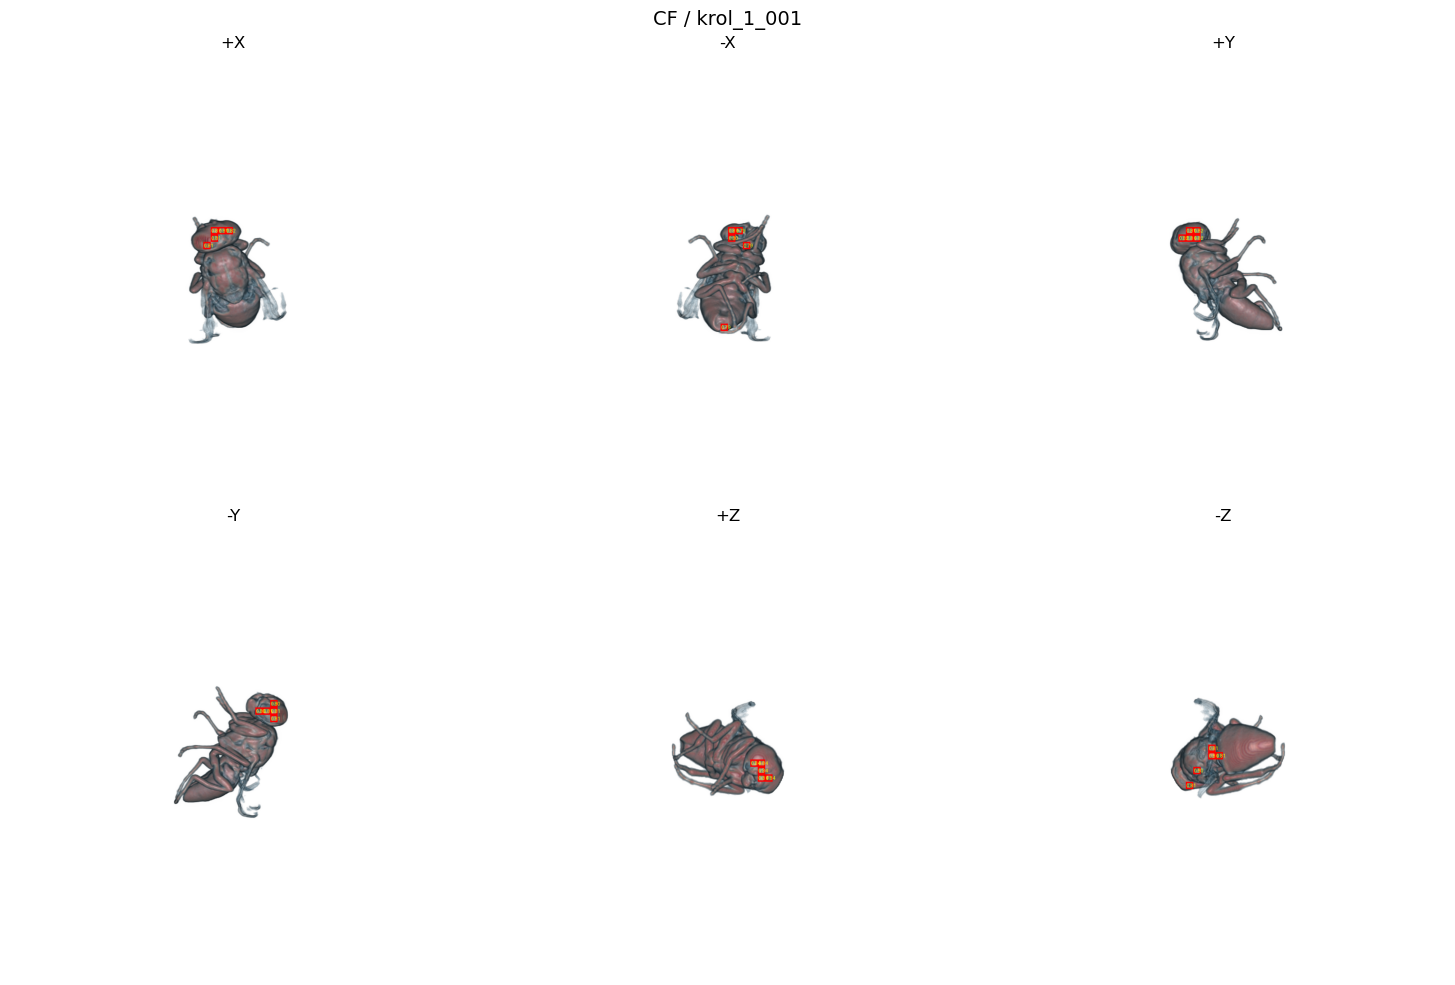

In [55]:
# Build median prototype and save
prototype_median = build_prototype_animal_median(animal, tokens_root, segmented_root)
np.save(tokens_root / animal / "prototype_vector.npy", prototype_median)

# Recompute similarities and top-k with new prototype
save_cosine_similarities(tokens_root, animal)
save_top_k_patches(tokens_root, animal, k=5)

# Visualise
plot_top_k_on_images(segmented_root, tokens_root, animal, individual)

In [56]:
for angle in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    angle_idx = ANGLE_TO_INDEX[angle]
    json_path = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}" / "top_k_patches.json"
    patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]
    print(f"{angle}: {[(p['patch_row'], p['patch_col'], round(p['cosine_similarity'], 3)) for p in patches]}")

+X: [(23, 27, 0.82), (23, 29, 0.816), (23, 28, 0.814), (25, 26, 0.811), (24, 27, 0.808)]
-X: [(23, 30, 0.801), (24, 30, 0.796), (23, 31, 0.794), (36, 29, 0.792), (25, 32, 0.79)]
+Y: [(24, 25, 0.827), (24, 24, 0.823), (24, 26, 0.821), (23, 26, 0.816), (23, 25, 0.811)]
-Y: [(24, 35, 0.812), (24, 34, 0.811), (25, 35, 0.811), (23, 35, 0.803), (24, 33, 0.801)]
+Z: [(33, 34, 0.844), (31, 34, 0.841), (32, 34, 0.839), (33, 35, 0.839), (31, 33, 0.838)]
-Z: [(29, 28, 0.81), (30, 28, 0.809), (34, 25, 0.807), (30, 29, 0.807), (32, 26, 0.803)]


In [57]:
from PIL import Image, ImageDraw

for angle in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    angle_idx = ANGLE_TO_INDEX[angle]
    img_path = segmented_root / animal / individual / f"{individual}_{angle_idx}_{angle}.png"
    json_path = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}" / "top_k_patches.json"
    
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]
    for p in patches:
        draw.rectangle([p["patch_x0"], p["patch_y0"], p["patch_x1"], p["patch_y1"]], outline="red", width=2)
    img.show()

In [58]:
from PIL import Image, ImageDraw

for angle in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    angle_idx = ANGLE_TO_INDEX[angle]
    img_path = segmented_root / animal / individual / f"{individual}_{angle_idx}_{angle}.png"
    json_path = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}" / "top_k_patches.json"
    
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]
    for p in patches:
        draw.rectangle([p["patch_x0"], p["patch_y0"], p["patch_x1"], p["patch_y1"]], outline="red", width=2)
    img.save(f"debug_{angle.replace('+','p').replace('-','m')}.png")

In [49]:
result2 = ransac_fuse(origins, dirs, 15, 3)
result2

{'point': array([152.09552178, 116.6184176 , 268.37513933]),
 'inliers': [1, 4, 10, 12, 13, 20, 21, 24, 27],
 'n_inliers': 9,
 'threshold': 15}

### Parallel

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing as mp

In [ ]:
def run_threaded(jobs, func, workers=8):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(func, job) for job in jobs]

        for f in as_completed(futures):
            f.result()

In [ ]:
def process_volume_worker(args):
    f, input_root, output_root = args

    animal_key = str(f.parts[-2])

    if animal_key not in animals:
        return

    process_volume(f, input_root, output_root)

In [ ]:
def head_information_worker(args):
    f, input_root, output_root, annotations = args

    animal_key = str(f.parts[-2])
    individual_key = str(f.parts[-1])

    if animal_key not in animals:
        return

    if animal_key not in annotations:
        return

    if individual_key not in annotations[animal_key]:
        return

    if not f.exists():
        return

    annotation_xyz = annotations[animal_key][individual_key]

    get_head_information(
        f,
        input_root,
        output_root,
        annotation_xyz,
    )

In [ ]:
def rotation_worker(args):
    animal, individual, segmented_root, tokens_root, original_path, info_path = args

    t_ind = time.time()

    origins, dirs = build_rays_from_individual(
        segmented_root,
        tokens_root,
        animal,
        individual,
    )

    if len(origins) < 2:
        return None

    result_ransac = ransac_fuse(
        origins,
        dirs,
        threshold=10,
        refine_iters=4,
    )

    if result_ransac is None:
        return None

    head_xyz = result_ransac["point"]

    mask_path = segmented_root / animal / individual / "mask.npz"
    mask = np.load(mask_path)["mask"]

    com_xyz = np.array(
        ndimage.center_of_mass(mask.astype(np.uint8)),
        dtype=float,
    )

    v_xyz = head_xyz - com_xyz

    in_path = original_path / animal / f"{individual}.tif"

    volume = vedo.load(str(in_path)).tonumpy()

    target_axis = axis_to_vector("+Y")

    rot = rotation_matrix_from_vectors(
        v_xyz,
        target_axis,
    )

    rotated = rotate_volume(
        volume,
        rot=rot,
        order=1,
    )

    out_tif_dir = info_path / "final" / animal
    out_tif_dir.mkdir(parents=True, exist_ok=True)

    out_tif = out_tif_dir / f"{individual}.tif"

    tifffile.imwrite(
        str(out_tif),
        rotated.astype(volume.dtype, copy=False),
    )

    final_out = info_path / "final_segmented"
    final_input_root = info_path / "final"

    process_volume(
        out_tif,
        final_input_root,
        final_out,
    )

    return (
        animal,
        individual,
        round(time.time() - t_ind, 2),
    )

In [ ]:
def run_all_timings_parallel(original_path, info_path):
    t_total = time.time()
    info_path.mkdir(parents=True, exist_ok=True)
    timings = {}
    
    path_anno = Path("Annoteringer/annotations_output/image_annotations.json")
    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    volumes    = find_input_volumes(original_path)
    input_root = original_path
    output_root = info_path / "segmented"

    # Processing .tif files, creating images from angles 
    workers = max(1, mp.cpu_count() - 1)

    t0 = time.time()

    jobs = [
        (f, input_root, output_root)
        for f in volumes
    ]

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(process_volume_worker, job) for job in jobs]

        for fut in as_completed(futures):
            fut.result()

    timings["process_volume"] = round(time.time() - t0, 2)
    log(f"[timing] process_volume: {timings['process_volume']}s")

    # Extracting head information
    t0 = time.time()

    jobs = [
        (f, input_root, output_root, annotations)
        for f in volumes
    ]

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(head_information_worker, job) for job in jobs]

        for fut in as_completed(futures):
            fut.result()

    timings["get_head_information"] = round(time.time() - t0, 2)
    log(f"[timing] get_head_information: {timings['get_head_information']}s")

    tokens_root     = info_path / "tokens"
    head_cords_root = info_path / "segmented"
    segmented_root  = info_path / "segmented"

    t0 = time.time()
    for animal in animals:
        extract_patch_tokens_animal(segmented_root, animal, processor, model, patch_size, bg_threshold, fg_patch_ratio, device)
    timings["extract_patch_tokens_animal"] = round(time.time() - t0, 2)
    log(f"[timing] extract_patch_tokens_animal: {timings['extract_patch_tokens_animal']}s")

    t0 = time.time()
    for animal in animals:
        prototype = build_prototype_animal(animal, tokens_root, head_cords_root)
        np.save(tokens_root / animal / "prototype_vector.npy", prototype)
    timings["build_prototype_animal"] = round(time.time() - t0, 2)
    log(f"[timing] build_prototype_animal: {timings['build_prototype_animal']}s")

    t0 = time.time()
    for animal in animals:
        save_cosine_similarities(tokens_root, animal)
    timings["save_cosine_similarities"] = round(time.time() - t0, 2)
    log(f"[timing] save_cosine_similarities: {timings['save_cosine_similarities']}s")

    t0 = time.time()
    for animal in animals:
        save_top_k_patches(tokens_root, animal, k=4)
    timings["save_top_k_patches"] = round(time.time() - t0, 2)
    log(f"[timing] save_top_k_patches: {timings['save_top_k_patches']}s")

    t0 = time.time()

    jobs = []

    for animal in animals:
        individuals = discover_segmented_individuals(
            tokens_root,
            animal,
        )

        for individual in individuals:
            jobs.append(
                (
                    animal,
                    individual,
                    segmented_root,
                    tokens_root,
                    original_path,
                    info_path,
                )
            )

    individual_timings = {}

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [
            ex.submit(rotation_worker, job)
            for job in jobs
        ]

        for fut in as_completed(futures):

            result = fut.result()

            if result is None:
                continue

            animal, individual, elapsed = result

            individual_timings[
                f"{animal}/{individual}"
            ] = elapsed

            log(
                f"[{animal} {individual}] "
                f"done in {elapsed}s"
            )

    timings["rotation_and_final_processing"] = round(time.time() - t0, 2)
    timings["individuals"] = individual_timings
    timings["total"] = round(time.time() - t_total, 2)
    log(f"[timing] total: {timings['total']}s")

    timings_path = info_path / "timings.json"
    timings_path.write_text(json.dumps(timings, indent=2), encoding="utf-8")
    log(f"[timing] saved to {timings_path}")

In [ ]:
# original_path = Path('data/original_photos')
# info_path = Path('data/test_dinov3_3')

# run_all_timings_parallel(original_path,info_path)

Processing volume: bcrick_1_000.tif
